## CMOS Battery Predictive Failure Analysis Using System Telemetry

#### A Short case-study on the problem
This part is for our understanding of the problem statement given to us and study on the domain knowledge of the problem before diving into data and model building so that we can know how our perspectives and impact in real world :)

### Case Study
- Modern computer systems rely on CMOS batteries to maintain  critical BIOS configurations and accurate system time.
- As it weakens, systems begin showing symptoms such as time resets,BIOS warnings, or boot errors.
- This results in several problems such as :
    - Loss of BIOS settings
    - Incorrect system time
    - Boot failures and system downtime
    - Increased maintenance and support costs

Currently, CMOS batteries are replaced reactively after failure, which disrupts system availability and increases operational risk.

So our goal in this project is to build a predictive model that uses measurable system signals (like voltage, clock drift,
and error logs) to identify early warning patterns and enable proactive maintenance.

If deployed, this hope our system can **reduce unplanned system downtime,lower maintenance costs by avoiding blanket replacements and improve system reliability and uptime**

**Performance Metric** : Model performance will be primarily evaluated using recall for failure cases (Failure_Label = 1), along ROC-AUC, to prioritize early detection of at-risk systems while tolerating a controlled level of false positives.

#### Importing libraries


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv('/content/CMOS_Battery_Failure_Dataset.csv')

In [ ]:
df.head()

,System_ID,Battery_Voltage,RTC_Drift_sec_per_day,Boot_Errors_Count,CMOS_Warning_Flag,Reset_BIOS_Flag,Power_Cycle_Count,System_Age_Years,Ambient_Temperature_C,Failure_Label
0,SYS-0000,3.07,43,1,1,0,1632,7.6,22.9,0
1,SYS-0001,2.92,41,0,0,1,540,6.3,30.0,0
2,SYS-0002,3.11,11,0,0,0,2577,7.3,33.6,0
3,SYS-0003,3.30,46,1,0,0,2118,7.4,30.2,0
4,SYS-0004,2.89,89,1,0,0,1398,7.9,40.8,0


In [ ]:
df.shape

# The dataset contains 5,000 telemetry records, each representing a system-level snapshot of
# CMOS battery health and system behavior.


(5000, 10)

In [ ]:
df.columns

Index(['System_ID', 'Battery_Voltage', 'RTC_Drift_sec_per_day',
       'Boot_Errors_Count', 'CMOS_Warning_Flag', 'Reset_BIOS_Flag',
       'Power_Cycle_Count', 'System_Age_Years', 'Ambient_Temperature_C',
       'Failure_Label'],
      dtype='object')

In [ ]:
features = df.columns.to_list()

In [ ]:
features

['System_ID',
 'Battery_Voltage',
 'RTC_Drift_sec_per_day',
 'Boot_Errors_Count',
 'CMOS_Warning_Flag',
 'Reset_BIOS_Flag',
 'Power_Cycle_Count',
 'System_Age_Years',
 'Ambient_Temperature_C',
 'Failure_Label']

### EDA

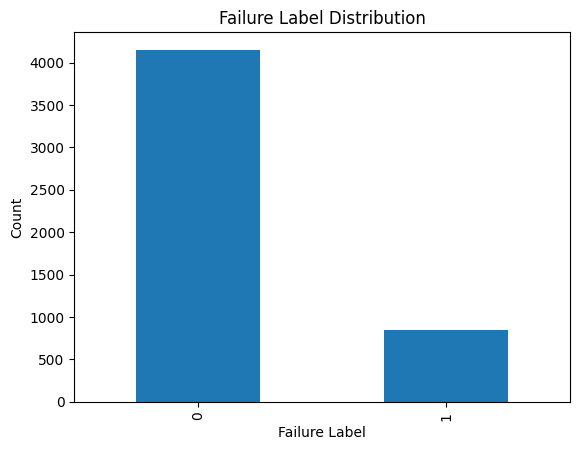

'\nWe can see from the visualisation below that there is an imbalance in the target distribution however we will\nsee if we should handle this for our model building later.\n\nlater infernece = Imbalance here is natural, not a data bug.\n'

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
plt.figure()
df["Failure_Label"].value_counts().plot(kind="bar")
plt.title("Failure Label Distribution")
plt.xlabel("Failure Label")
plt.ylabel("Count")
plt.show()

"""
We can see from the visualisation below that there is an imbalance in the target distribution however we will
see if we should handle this for our model building later.

later infernece = Imbalance here is natural, not a data bug.
"""


In [ ]:
df.head()

,System_ID,Battery_Voltage,RTC_Drift_sec_per_day,Boot_Errors_Count,CMOS_Warning_Flag,Reset_BIOS_Flag,Power_Cycle_Count,System_Age_Years,Ambient_Temperature_C,Failure_Label
0,SYS-0000,3.07,43,1,1,0,1632,7.6,22.9,0
1,SYS-0001,2.92,41,0,0,1,540,6.3,30.0,0
2,SYS-0002,3.11,11,0,0,0,2577,7.3,33.6,0
3,SYS-0003,3.30,46,1,0,0,2118,7.4,30.2,0
4,SYS-0004,2.89,89,1,0,0,1398,7.9,40.8,0


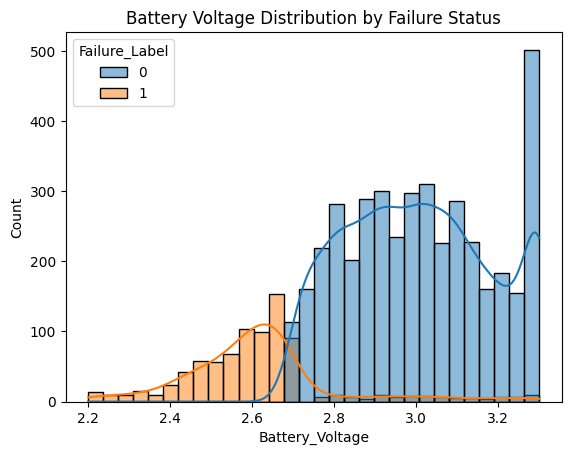

In [ ]:
plt.figure()
sns.histplot(data=df, x="Battery_Voltage", hue="Failure_Label", bins=30, kde=True)
plt.title("Battery Voltage Distribution by Failure Status")
plt.show()

# voltage has strong signal :)

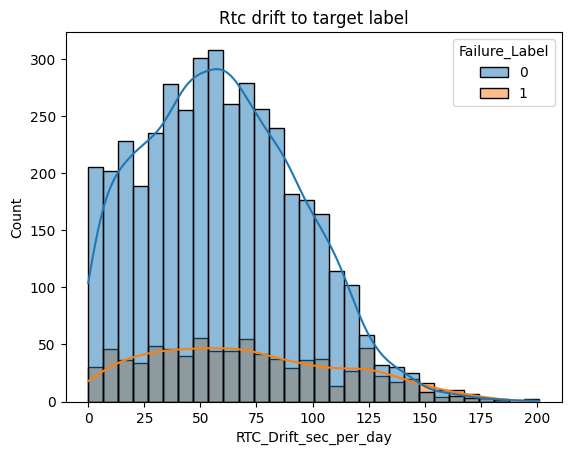

In [ ]:
plt.figure()
sns.histplot(data=df , x='RTC_Drift_sec_per_day' , hue='Failure_Label' , bins=30 , kde = True)
plt.title("Rtc drift to target label")
plt.show()

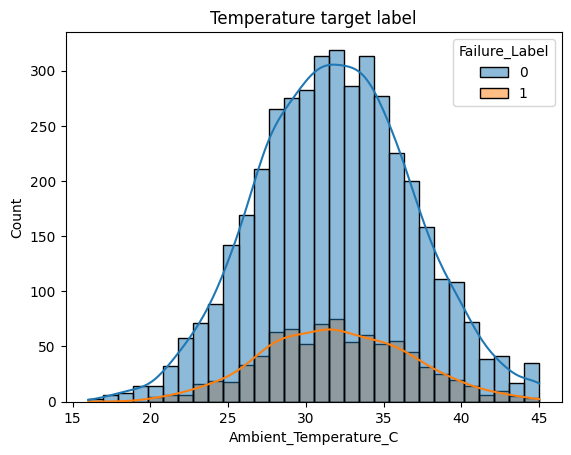

In [ ]:
plt.figure()
sns.histplot(data=df , x='Ambient_Temperature_C' , hue='Failure_Label' , bins=30 , kde = True)
plt.title("Temperature target label")
plt.show()

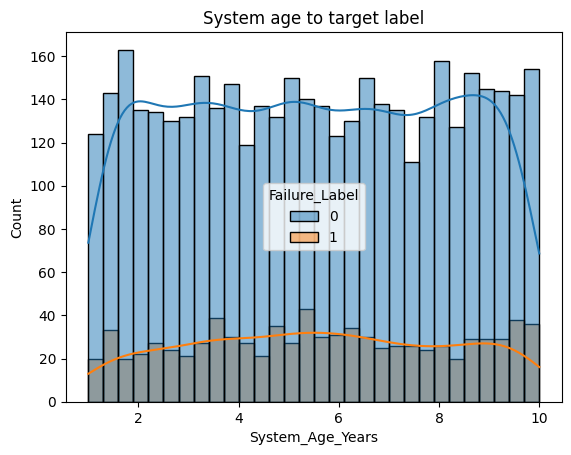

In [ ]:
plt.figure()
sns.histplot(data=df , x='System_Age_Years' , hue='Failure_Label' , bins=30 , kde = True)
plt.title("System age to target label")
plt.show()

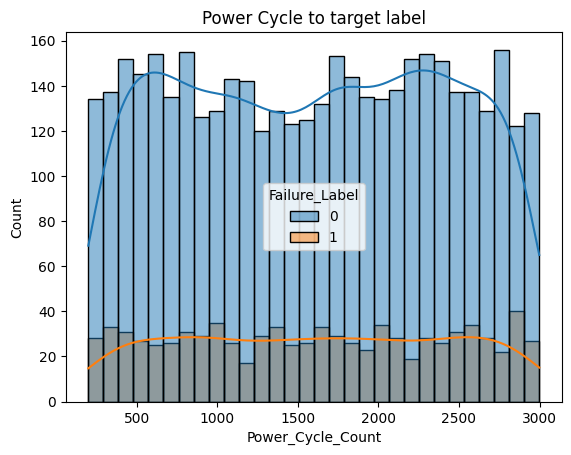

In [ ]:
plt.figure()
sns.histplot(data=df , x='Power_Cycle_Count' , hue='Failure_Label' , bins=30 , kde = True)
plt.title("Power Cycle to target label")
plt.show()

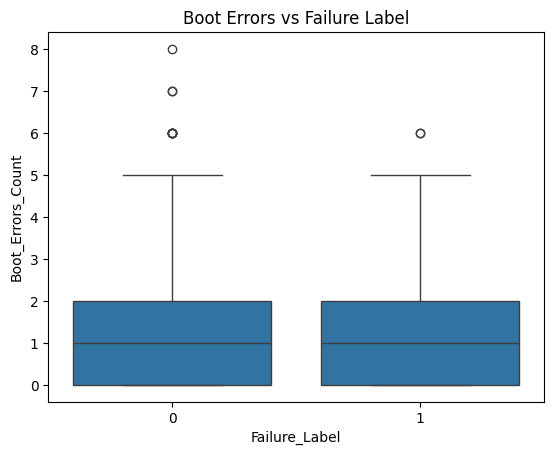

In [ ]:
# target distribution wrt to binary type features
plt.figure()
sns.boxplot(data=df, x="Failure_Label", y="Boot_Errors_Count")
plt.title("Boot Errors vs Failure Label")
plt.show()


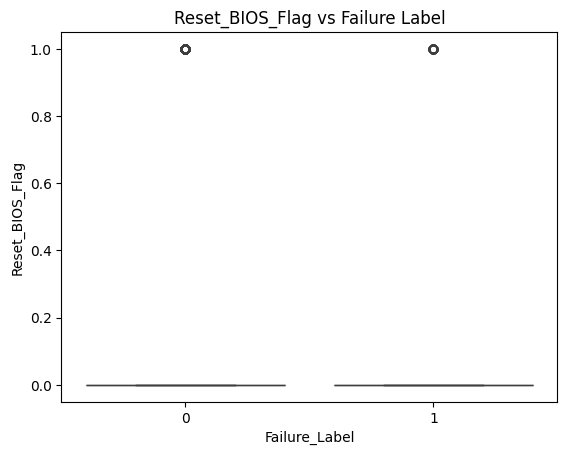

In [ ]:
plt.figure()
sns.boxplot(data=df, x="Failure_Label", y="Reset_BIOS_Flag")
plt.title("Reset_BIOS_Flag vs Failure Label")
plt.show()


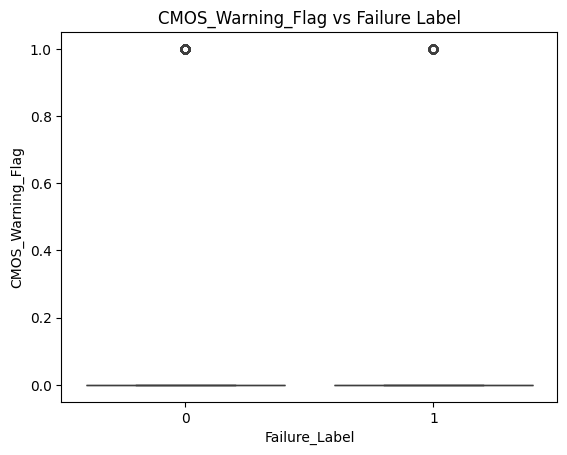

In [ ]:
plt.figure()
sns.boxplot(data=df, x="Failure_Label", y="CMOS_Warning_Flag")
plt.title("CMOS_Warning_Flag vs Failure Label")
plt.show()


In [ ]:
features

['System_ID',
 'Battery_Voltage',
 'RTC_Drift_sec_per_day',
 'Boot_Errors_Count',
 'CMOS_Warning_Flag',
 'Reset_BIOS_Flag',
 'Power_Cycle_Count',
 'System_Age_Years',
 'Ambient_Temperature_C',
 'Failure_Label']

In [ ]:
# drop id column
df.drop(columns='System_ID', inplace=True)

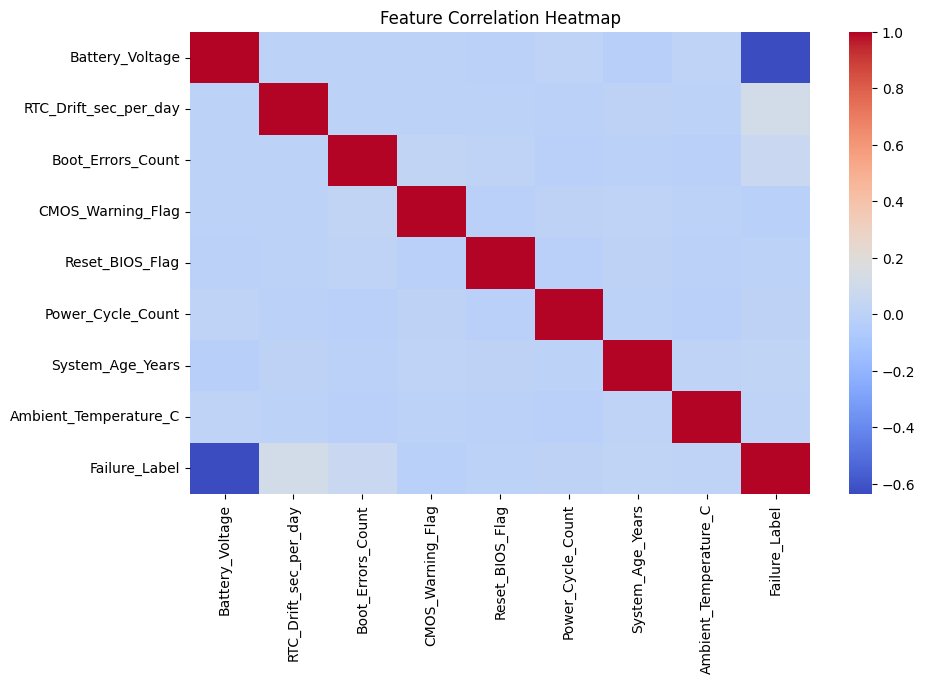

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


### **EDA Insights :**
- The dataset is significantly imbalanced, with the majority of systems labeled as healthy (Failure_Label = 0) and a smaller fraction labeled as at risk (Failure_Label = 1).

- This confirms that CMOS battery failure is a rare event,hence i guess we need recall focused metrics.
(accuracy alone can be misleading)

- Battery Voltage Is the Strongest Individual Indicator.
  - Battery voltage shows clear separation between healthy and failing systems.
  - At-risk systems are heavily concentrated at lower voltage ranges (~2.2-2.7V), while healthy systems dominate higher voltages.

- Temperature distributions for healthy and failing systems largely overlap.
    - However, failing systems show slightly higher density at elevated temperatures, supporting the hypothesis that heat accelerates battery degradation.

- System Age and Power Cycles Are Weak Individually
- Boot Errors Show Non-Linear Behavior
- Correlation Analysis Confirms Non-Linear Nature which means

 -  **Tree-based models and engineered interaction features are well-suited for this problem.**

In [ ]:
df.isna().sum()

,0
Battery_Voltage,0
RTC_Drift_sec_per_day,0
Boot_Errors_Count,0
CMOS_Warning_Flag,0
Reset_BIOS_Flag,0
Power_Cycle_Count,0
System_Age_Years,0
Ambient_Temperature_C,0
Failure_Label,0


### Feature Engineering

In [ ]:
print(features)

['System_ID', 'Battery_Voltage', 'RTC_Drift_sec_per_day', 'Boot_Errors_Count', 'CMOS_Warning_Flag', 'Reset_BIOS_Flag', 'Power_Cycle_Count', 'System_Age_Years', 'Ambient_Temperature_C', 'Failure_Label']


In [ ]:
import numpy as np
import pandas as pd


df_fe = df.copy()

def feature_engineering(df_fe):
  # Ratio / Normalized Features

  df_fe["voltage_per_year"] = df_fe["Battery_Voltage"] / (df_fe["System_Age_Years"] + 1e-3)

  df_fe["rtc_drift_per_year"] = df_fe["RTC_Drift_sec_per_day"] / (df_fe["System_Age_Years"] + 1e-3)

  df_fe["errors_per_1000_cycles"] = (
      df_fe["Boot_Errors_Count"] / (df_fe["Power_Cycle_Count"] + 1)
  ) * 1000


  #  Interaction Features

  df_fe["voltage_temperature_interaction"] = (
      df_fe["Battery_Voltage"] * df_fe["Ambient_Temperature_C"]
  )
  df_fe["voltage_rtc_interaction"] = (
      df_fe["Battery_Voltage"] * df_fe["RTC_Drift_sec_per_day"]
  )
  df_fe["age_temperature_interaction"] = (
      df_fe["System_Age_Years"] * df_fe["Ambient_Temperature_C"]
  )

  #  Soft Risk Threshold Flags
  df_fe["low_voltage_flag"] = (df_fe["Battery_Voltage"] < 2.7).astype(int)
  df_fe["high_temperature_flag"] = (df_fe["Ambient_Temperature_C"] > 35).astype(int)


  #  Log Scaling for Skewed Counts
  df_fe["log_power_cycles"] = np.log1p(df_fe["Power_Cycle_Count"])
  df_fe["log_boot_errors"] = np.log1p(df_fe["Boot_Errors_Count"])
  return df_fe

df_fe = feature_engineering(df_fe)

# Final Check
df_fe.head()


,Battery_Voltage,RTC_Drift_sec_per_day,Boot_Errors_Count,CMOS_Warning_Flag,Reset_BIOS_Flag,Power_Cycle_Count,System_Age_Years,Ambient_Temperature_C,Failure_Label,voltage_per_year,rtc_drift_per_year,errors_per_1000_cycles,voltage_temperature_interaction,voltage_rtc_interaction,age_temperature_interaction,low_voltage_flag,high_temperature_flag,log_power_cycles,log_boot_errors
0,3.07,43,1,1,0,1632,7.6,22.9,0,0.403894,5.657150,0.612370,70.303,132.01,174.04,0,0,7.398174,0.693147
1,2.92,41,0,0,1,540,6.3,30.0,0,0.463419,6.506904,0.000000,87.600,119.72,189.00,0,0,6.293419,0.000000
2,3.11,11,0,0,0,2577,7.3,33.6,0,0.425969,1.506643,0.000000,104.496,34.21,245.28,0,0,7.854769,0.000000
3,3.30,46,1,0,0,2118,7.4,30.2,0,0.445886,6.215376,0.471921,99.660,151.80,223.48,0,0,7.658700,0.693147
4,2.89,89,1,0,0,1398,7.9,40.8,0,0.365776,11.264397,0.714796,117.912,257.21,322.32,0,1,7.243513,0.693147


In [ ]:
df_fe.shape

(5000, 19)

### Baseline modelling

> Before training complex models, a simple and interpretable baseline is established to:
- Validate that engineered features carry predictive signal
- Provide a reference point for performance comparison



In [ ]:
  from sklearn.model_selection import train_test_split
  from sklearn.linear_model import LogisticRegression
  from sklearn.preprocessing import StandardScaler
  from sklearn.metrics import classification_report, roc_auc_score ,recall_score

# Separate features and target
X = df_fe.drop(columns=["Failure_Label"])
y = df_fe["Failure_Label"]

# Stratified split due to class imbalance
# Why stratified?
# Because we want the failure ratio to remain the same in train and test.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


log_reg = LogisticRegression(
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)


# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print()
recall_failure = recall_score(y_test, y_pred, pos_label=1)
print("Recall (Failure Class):", recall_failure)

              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1038
           1       0.95      0.99      0.97       212

    accuracy                           0.99      1250
   macro avg       0.97      0.99      0.98      1250
weighted avg       0.99      0.99      0.99      1250

ROC-AUC: 0.9995682917075653

Recall (Failure Class): 0.9858490566037735


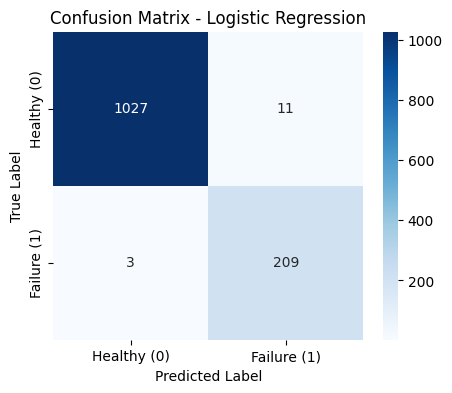

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy (0)", "Failure (1)"],
    yticklabels=["Healthy (0)", "Failure (1)"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


Although the baseline model achieves near-perfect recall and ROC-AUC, this result warrants careful interpretation.  
Since the failure labels are derived from rule-based thresholds on voltage and system behavior, some engineered features may closely mirror the label generation logic.

#### Random forest before moving on to xgboost and stuff


In [ ]:
df_fe = feature_engineering(df)


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       830
           1       1.00      1.00      1.00       170

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC: 1.0
Recall (Failure Class): 1.0
Precision :  1.0
Accuracy :  1.0


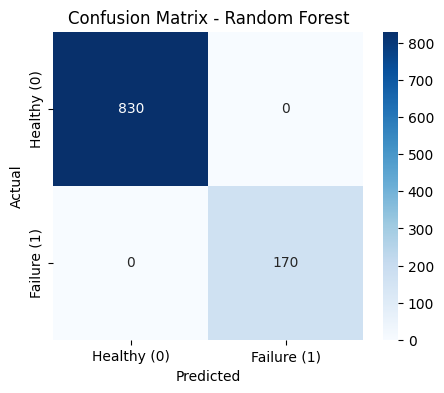

In [ ]:
from sklearn.model_selection import train_test_split

# Features & target
X = df_fe.drop(columns=["Failure_Label"])
y = df_fe["Failure_Label"]

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,          # let trees grow, we’ll control later
    class_weight="balanced", # handle imbalance
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, recall_score , precision_score , accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Metrics
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("Recall (Failure Class):", recall_score(y_test, y_pred_rf))
print('Precision : ' , precision_score(y_test, y_pred_rf))
print('Accuracy : ', accuracy_score(y_test , y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy (0)", "Failure (1)"],
    yticklabels=["Healthy (0)", "Failure (1)"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


doubts until here :

> According to me generally its not 100% predictable for any model which works in production , but our all above models have been showing 100% recall or metric scores which doubts me if there is any data leakage ...



In [ ]:
importances = rf.feature_importances_

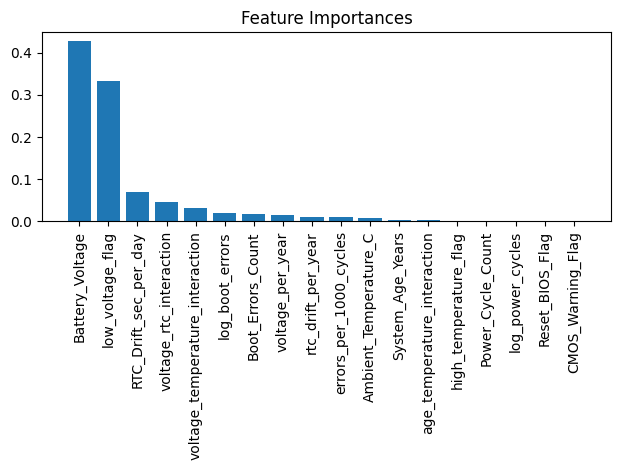

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

plt.figure()
plt.bar(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xticks(rotation=90)
plt.title("Feature Importances")
plt.tight_layout()
plt.show()


### Experiment 2 - dropping highly correlated features and retraining

In [ ]:
df_fe.columns

Index(['Battery_Voltage', 'RTC_Drift_sec_per_day', 'Boot_Errors_Count',
       'CMOS_Warning_Flag', 'Reset_BIOS_Flag', 'Power_Cycle_Count',
       'System_Age_Years', 'Ambient_Temperature_C', 'Failure_Label',
       'voltage_per_year', 'rtc_drift_per_year', 'errors_per_1000_cycles',
       'voltage_temperature_interaction', 'voltage_rtc_interaction',
       'age_temperature_interaction', 'low_voltage_flag',
       'high_temperature_flag', 'log_power_cycles', 'log_boot_errors'],
      dtype='object')

In [ ]:
target_corr = (
    df_fe.corr(numeric_only=True)["Failure_Label"]
    .sort_values(ascending=False)
)

print(target_corr)

Failure_Label                      1.000000
low_voltage_flag                   0.926691
RTC_Drift_sec_per_day              0.117576
Boot_Errors_Count                  0.062539
log_boot_errors                    0.060387
rtc_drift_per_year                 0.041755
errors_per_1000_cycles             0.038849
voltage_rtc_interaction            0.035917
age_temperature_interaction        0.020484
System_Age_Years                   0.017371
Ambient_Temperature_C              0.012413
high_temperature_flag              0.004492
Power_Cycle_Count                  0.003643
log_power_cycles                   0.001001
Reset_BIOS_Flag                   -0.000124
CMOS_Warning_Flag                 -0.017815
voltage_per_year                  -0.087268
voltage_temperature_interaction   -0.276036
Battery_Voltage                   -0.635235
Name: Failure_Label, dtype: float64


In [ ]:
# removing three highly correlated features
df_fe.drop(columns=['low_voltage_flag' , 'Battery_Voltage','voltage_temperature_interaction'] , inplace=True)


Mean Accuracy: 0.8822000000000001
Mean Precision: 0.9523348547642911
Mean Recall: 0.322798468499826
Mean ROC-AUC: 0.9292992117776036


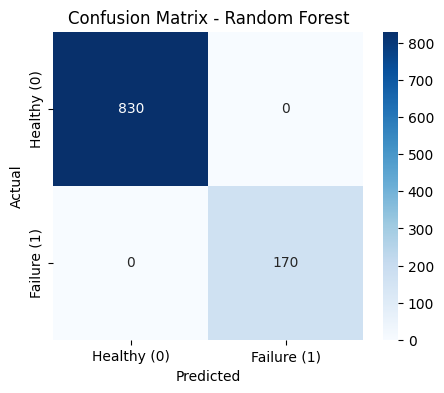

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Features & target
X = df_fe.drop(columns=["Failure_Label"])
y = df_fe["Failure_Label"]


# Model
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

# Stratified KFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Multiple scoring metrics
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    rf,
    X,
    y,
    cv=skf,
    scoring=scoring,
    return_train_score=False
)

# Print mean scores
print("Mean Accuracy:", np.mean(cv_results["test_accuracy"]))
print("Mean Precision:", np.mean(cv_results["test_precision"]))
print("Mean Recall:", np.mean(cv_results["test_recall"]))
print("Mean ROC-AUC:", np.mean(cv_results["test_roc_auc"]))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy (0)", "Failure (1)"],
    yticklabels=["Healthy (0)", "Failure (1)"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [ ]:
import joblib
rf.fit(X_train, y_train)

# 3. SAVE (Make sure you save the 'rf_model' variable specifically)
joblib.dump(rf, 'model.pkl')




['model.pkl']